Figure S10: eGene colocalization. A Number of eGenes colocalized in each credible set group split by whether the group is eQTL only or both a pcQTL and eQTL. B  Distribution of the number of genes in a cluster vs the number of genes that are single-gene eQTLs for  credible set groups that contain both eQTLs and pcQTLs. 2,291 credible set groups contain a single-gene eQTL for every gene in the cluster. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm

tqdm.pandas()

# get outputs from a config file
prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *
from annotate_clusters import * 
from annotate_null_clusters import * 
from get_pcs import * 


%config InlineBackend.figure_formats = ['png']

plt.rcParams.update({
    'font.size': 8,           # Base font size
    'axes.labelsize': 9,      # Axis labels
    'axes.titlesize': 10,     # Subplot titles
    'xtick.labelsize': 8,     # X-axis tick labels
    'ytick.labelsize': 8,     # Y-axis tick labels
    'legend.fontsize': 8,     # Legend
    'pdf.fonttype': 42,       # Embed fonts in PDF
    'ps.fonttype': 42,        # Embed fonts in PS
})

In [9]:
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['cluster_id_short'] = qtl_signal_groups['cluster_id'].str.split('_').str[-1] + '_' + qtl_signal_groups['tissue_id']
qtl_signal_groups['exclusive_label'] = np.where((qtl_signal_groups['num_e_coloc'] > 0), np.where((qtl_signal_groups['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')



clusters = load_across_tissues(config, load_cluster)
clusters['cluster_id_short'] = clusters['cluster_id'].str.split('_').str[-1] + '_' + clusters['tissue_id']
qtl_signal_groups = pd.merge(qtl_signal_groups, clusters[['cluster_id_short', 'num_genes']], on='cluster_id_short', how='left')

In [14]:
def count_unique_egenes(signal_id):
    parts = signal_id.split('-')
    egenes = set()
    for part in parts:
        if '_e_' in part and '_pc' not in part:
            match = re.search(r'_e_(.*?)_cs_', part)
            if match:
                genes_str = match.group(1)
                gene_ids = [g for g in genes_str.split('_') if g.startswith('ENSG')]
                egenes.update(gene_ids)
    return len(egenes)

qtl_signal_groups['num_egenes'] = qtl_signal_groups['signal_id'].apply(count_unique_egenes)

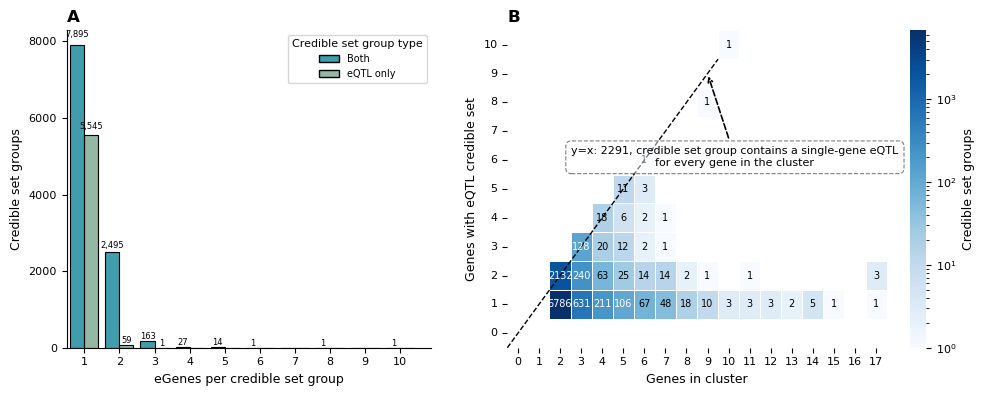

In [ ]:
# Combine the histogram (original selection) as panel A and the heatmap (from file_context_0) as panel B

fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [1, 1.3]})

# --- Panel A: Histogram as before, but in axes[0] ---
ax = axes[0]
hist_data = qtl_signal_groups[qtl_signal_groups['num_egenes'] > 0]
bars = sns.histplot(
    hist_data, x='num_egenes',
    discrete=True, ax=ax, hue='exclusive_label', multiple='dodge',
    legend=True, palette=qtl_palette, shrink=0.8
)

# Add value labels to histogram bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2., height + height * 0.02,
                f'{int(height):,}', ha='center', va='bottom', fontsize=6, rotation=0
            )
sns.move_legend(ax, "upper right", bbox_to_anchor=(1, 1), fontsize=7, title_fontsize=8, title='Credible set group type')

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('eGenes per credible set group')
ax.set_ylabel('Credible set groups')
ax.set_xticks(range(11))
ax.set_xlim(.5, ax.get_xlim()[1])
ax.set_yticks([0, 2000, 4000, 6000, 8000])
ax.set_title('A', loc='left', fontsize=12, fontweight='bold')


# --- Panel B: Heatmap (from file_context_0, but in axes[1]) ---
# Only use the 'Both' qtl signal groups throughout
both_qtl = qtl_signal_groups[qtl_signal_groups['exclusive_label'] == 'Both']

min_genes = 0
max_genes = int(both_qtl['num_genes'].max())
min_e_coloc = 0
max_e_coloc = int(both_qtl['num_egenes'].max())

row_range = np.arange(min_genes, max_genes + 1)
col_range = np.arange(min_e_coloc, max_e_coloc + 1)

heatmap_data = pd.crosstab(
    both_qtl['num_genes'],
    both_qtl['num_egenes']
).reindex(index=row_range, columns=col_range, fill_value=0).T  # transpose

ax2 = axes[1]
masked = heatmap_data == 0

sns.heatmap(
    heatmap_data,
    cmap="Blues",
    cbar_kws={'label': 'Credible set groups'},
    linewidths=0.5,
    square=False,
    ax=ax2,
    norm=LogNorm(
        vmin=heatmap_data[heatmap_data > 0].min().min() if (heatmap_data > 0).any().any() else 1,
        vmax=heatmap_data.max().max()),
    mask=masked
)

ax2.invert_yaxis()

# Annotate cells
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if value != 0:
            ax2.text(
                j + 0.5, i + 0.5, str(int(value)),
                ha="center", va="center", color="white" if value > heatmap_data.values.max()/100 else "black",
                fontsize=7
            )

# y = x line with axes switched (see file_context_0)
xy_min = max(row_range.min(), col_range.min())
xy_max = min(row_range.max(), col_range.max())
ax2.plot([xy_min - min_genes, xy_max - min_genes], [xy_min - min_e_coloc, xy_max - min_e_coloc], 'k--', lw=1, zorder=2)

# Exact match annotation
exact_match_count = (both_qtl['num_genes'] == both_qtl['num_egenes']).sum()
annotation_xy = (0.6*heatmap_data.shape[1], 0.6*heatmap_data.shape[0])
target_num = 9
if (target_num in heatmap_data.index) and (target_num in heatmap_data.columns):
    target_coord = (
        list(heatmap_data.columns).index(target_num) + 0.5,
        list(heatmap_data.index).index(target_num) + 0.5
    )
else:
    y_equals_x_coord = (xy_min - min_genes + 0.5, xy_min - min_e_coloc + 0.5)
    target_coord = y_equals_x_coord
ax2.annotate(
    f'y=x: {exact_match_count}, credible set group contains a single-gene eQTL\nfor every gene in the cluster',
    xy=target_coord,
    xytext=annotation_xy,
    fontsize=8,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', linewidth=0.8, linestyle='--', alpha=0.5),
    arrowprops=dict(arrowstyle='->', lw=1.2, color='black', linestyle='--'),
    horizontalalignment='center',
    verticalalignment='center'
)

ax2.set_xticks(np.arange(heatmap_data.shape[1]) + 0.5)
ax2.set_xticklabels(heatmap_data.columns, rotation=0)
ax2.set_yticks(np.arange(heatmap_data.shape[0]) + 0.5)
ax2.set_yticklabels(heatmap_data.index, rotation=0)
ax2.set_ylabel("Genes with eQTL credible set")
ax2.set_xlabel("Genes in cluster")
ax2.set_title('B', loc='left', fontsize=12, fontweight='bold')

plt.tight_layout(w_pad=3)
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s10.pdf",
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()